In [1]:
import torch
import torch.nn.functional as f
import matplotlib.pyplot as plt 
%matplotlib inline

In [2]:
words = open('C:/Users/Acer/OneDrive/Desktop/YZ50/Week_3/names.txt','r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [34]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
itos

{1: 'a',
 2: 'b',
 3: 'c',
 4: 'd',
 5: 'e',
 6: 'f',
 7: 'g',
 8: 'h',
 9: 'i',
 10: 'j',
 11: 'k',
 12: 'l',
 13: 'm',
 14: 'n',
 15: 'o',
 16: 'p',
 17: 'q',
 18: 'r',
 19: 's',
 20: 't',
 21: 'u',
 22: 'v',
 23: 'w',
 24: 'x',
 25: 'y',
 26: 'z',
 0: '.'}

In [12]:
context = [0] * 3
context

[0, 0, 0]

In [27]:
block_size = 3

def build_dataset(words):
    
    X, Y = [], []
    
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]
            
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    
    return X,Y


In [32]:
import random

random.seed(42)
random.shuffle(words)

n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

In [293]:
# MLP revised 

n_embd = 10 # number of direction of character embeding
n_hidden  = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size,n_embd), generator=g) # embeding matrix (27,10)
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3) / (n_embd * block_size)**0.5 # (270,200)
b1 = torch.randn(n_hidden, generator=g) * 0
W2 = torch.randn((n_hidden, vocab_size), generator=g) * 0.1 # (200,27)
b2 = torch.randn(vocab_size,generator=g) * 0

bngain = torch.ones((1,n_hidden))
bnbias = torch.zeros((1,n_hidden))

parameters = [C,W1,b1,W2,b2, bngain, bnbias]

print(sum(p.nelement() for p in parameters)) # number of parameters
for p in parameters:
    p.requires_grad = True

12297


In [294]:
max_steps = 200000
batch_size = 32
lossi = []

for i in range(max_steps):
    
    ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
    Xb, Yb = Xtr[ix], Ytr[ix]
    
    emb = C[Xb]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = embcat @ W1 + b1
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias
    h = torch.tanh(hpreact)
    logits = h @ W2 + b2
    logits_softmax = f.softmax(logits)
    loss = f.cross_entropy(logits,Yb)
    
    for p in parameters:
        p.grad = None
    loss.backward()
    
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad 
    
    if i %10000 == 0:
        print(f'{i:7d}/{max_steps:7d}:{loss.item():.4f}')
    lossi.append(loss.log10().item())
    break
    

    

      0/ 200000:3.7624


C:\Users\Acer\AppData\Local\Temp\ipykernel_15680\966855326.py:16: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  logits_softmax = f.softmax(logits)


In [292]:
print(embcat.shape)
print(W1.shape)
print(hpreact.shape)
print(hpreact.std())

torch.Size([32, 30])
torch.Size([30, 200])
torch.Size([32, 200])
tensor(1.607707, grad_fn=<StdBackward0>)


In [179]:
emb.shape

torch.Size([32, 3, 10])

In [201]:
probs = f.softmax(logits)
loss = -torch.log(probs[torch.arange(len(Yb)),Yb]).mean()
loss


C:\Users\Acer\AppData\Local\Temp\ipykernel_15680\3711737509.py:1: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  probs = f.softmax(logits)


tensor(26.227415, grad_fn=<NegBackward0>)

In [202]:
torch.set_printoptions(sci_mode=False, precision=6)
print(logits[0])
print(probs[0])
print(-torch.log(probs[0]))

tensor([  2.479015,   3.063385,   8.517849, -25.560934,  27.956619,  25.766890,
          0.933379,  -9.455451,  -9.615530,  15.449617,  12.528598, -10.218143,
         13.302588,  -2.258730,   4.971161,  -0.784860, -19.738409,  23.366535,
         12.259960,   0.879114,  16.813786,  -3.043135,  -0.934745,   9.176914,
        -13.416376,  26.647560,   5.944464], grad_fn=<SelectBackward0>)
tensor([    0.000000,     0.000000,     0.000000,     0.000000,     0.718292,
            0.080411,     0.000000,     0.000000,     0.000000,     0.000003,
            0.000000,     0.000000,     0.000000,     0.000000,     0.000000,
            0.000000,     0.000000,     0.007292,     0.000000,     0.000000,
            0.000010,     0.000000,     0.000000,     0.000000,     0.000000,
            0.193992,     0.000000], grad_fn=<SelectBackward0>)
tensor([25.808483, 25.224113, 19.769650, 53.848434,  0.330880,  2.520609,
        27.354120, 37.742950, 37.903030, 12.837881, 15.758901, 38.505642,
      

In [ ]:
l = -torch.log(torch.tensor(1/27)) 
l

tensor(3.295837)

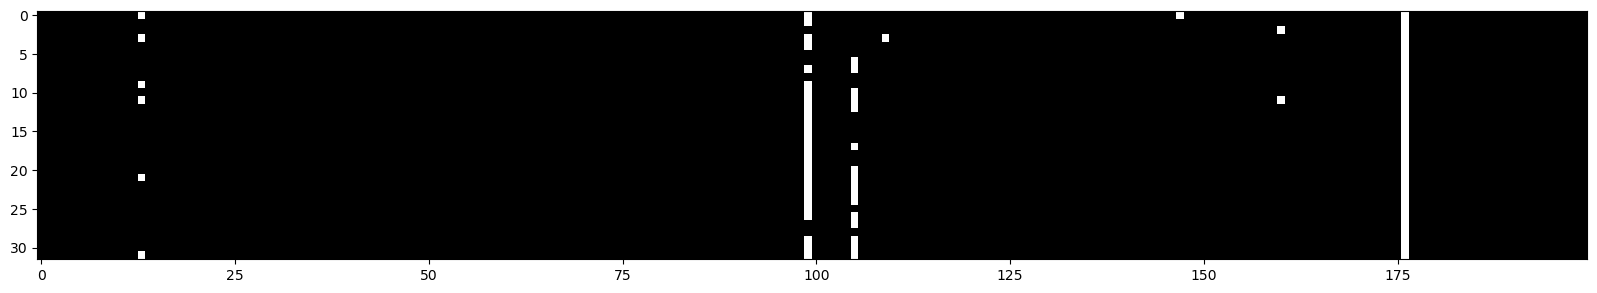

In [217]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs()>0.99,cmap='gray', interpolation='nearest')

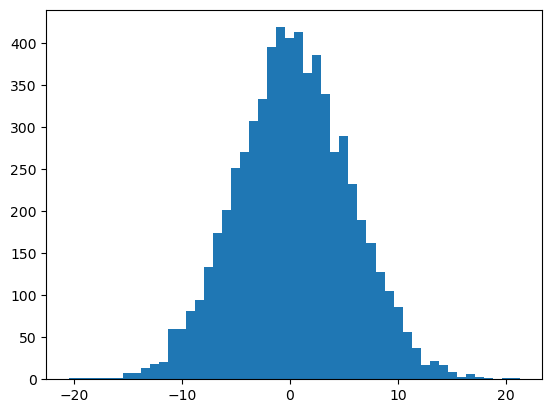

In [282]:
plt.hist(hpreact.view(-1).tolist(),50);

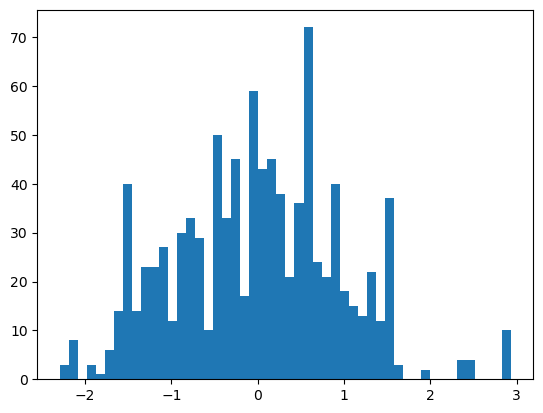

In [283]:
plt.hist(embcat.view(-1).tolist(),50);

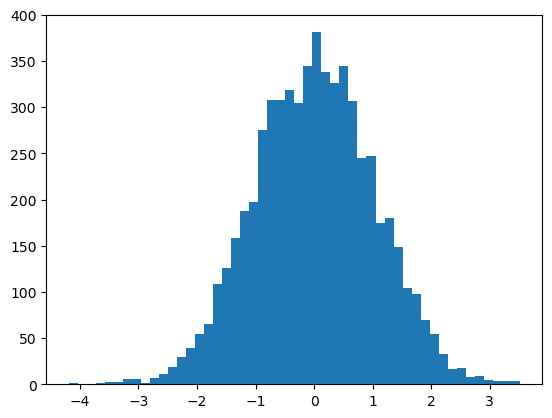

In [284]:
plt.hist(W1.view(-1).tolist(),50);

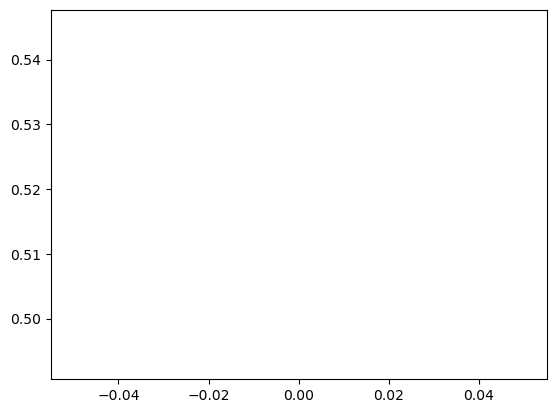

In [196]:
plt.plot(lossi)

tensor(-0.014331) tensor(1.006226)
tensor(-0.000808) tensor(1.000056)


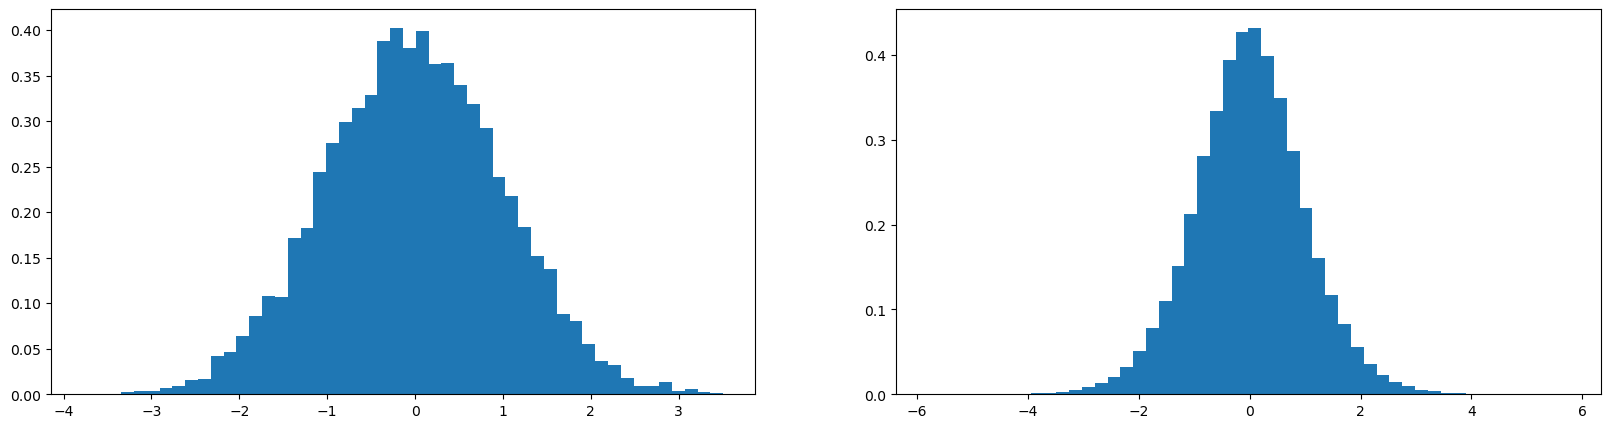

In [ ]:
x = torch.randn(1000,10) 
w = torch.randn(10,200) / 10**0.5
y = x @ w #(1000,200) 

print(x.mean(), x.std())
print(y.mean(), y.std())

plt.figure(figsize=(20,5))
plt.subplot(121)
plt.hist(x.view(-1).tolist(),50, density=True);
plt.subplot(122)
plt.hist(y.view(-1).tolist(),50,density=True);


In [ ]:
@torch.no_grad()

def split_loss(split):
    x,y = {
        'train': (Xtr,Ytr),
        'val': (Xdev,Ydev),
        'test': (Xte,Yte)
    }[split]
    emb = C[x]
    embcat = emb.view(emb.shape[0],-1)
    hpreact = bngain * (hpreact - hpreact.mean(0,keepdim=True)) / hpreact.std(0,keepdim=True) + bnbias
    h = torch.tanh(embcat @ W1 + b1)
    logits = h @ W2 + b2
    loss = f.cross_entropy(logits,y)
    print(split,loss.item())

: 

In [77]:
split_loss('train')
split_loss('val')
split_loss('test')

train 2.1198270320892334
val 2.1778151988983154
test 2.1669301986694336


In [98]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size
    while True:
        
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = f.softmax(logits,dim=1)
        ix = torch.multinomial(probs,num_samples=1,generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break
        
    
    print(''.join(itos[i] for i in out))

    

mona.
mayah.
see.
mel.
ryla.
rethra.
endra.
gradelynnelin.
shi.
jenrekenson.
anareelyn.
malaiahn.
shubergahimiel.
kindreeller.
novana.
ubeka.
dariyah.
faeha.
kayshuston.
mahil.
